#  BinWaves North Carolina Satellite Correction - NC-SC (Reconstruction)

**In this notebook**: 
<br><br>
Here waves are reconstructed in a selected grid.
<br><br>
Steps:
- Kp propagation coefficients and hindcast reconstruction is made at a grid.

In [1]:
import xarray as xr

# Load all the gridded kps and reproject

kp_coeffs = xr.open_dataset("outputs_NC_SC/kp_coefficients.nc")
kp_coeffs

<xarray.Dataset> Size: 15GB
Dimensions:   (case_num: 694, site: 3738, freq: 31, dir: 24)
Coordinates:
  * case_num  (case_num) int64 6kB 0 2 3 4 5 6 7 ... 689 690 691 692 693 694 695
  * site      (site) int64 30kB 1 2 3 4 5 6 7 ... 3733 3734 3735 3736 3737 3738
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 12.5 27.5 42.5 57.5 ... 312.5 327.5 342.5 357.5
    lat       float64 8B ...
    lon       float64 8B ...
    utm_x     (site) float64 30kB ...
    utm_y     (site) float64 30kB ...
Data variables:
    kps       (case_num, site, freq, dir) float64 15GB ...

In [2]:
import pandas as pd
from utils.operations import transform_ERA5_spectrum

model_parameters = pd.read_csv("NC_SC/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
# specify which range should have the spectra
offshore_spectra, offshore_spectra_case = transform_ERA5_spectrum(
    era5_spectrum=xr.open_dataset("common_inputs/satellite_corrected_44088_spectrum_cal.nc"),
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    satellite_correction=True,
    target_epsg="EPSG:32618" # This is the UTM zone 18N for North Carolina
)
offshore_spectra_case

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


<xarray.DataArray 'efth' (case_num: 694, time: 405963)> Size: 2GB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.71341895e-19],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.86616687e-18],
       ...,
       [0.00000000e+00, 6.08661044e-27, 2.46071238e-22, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.85256781e-27, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 7.15261264e-25, 8.06842138e-23, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(694, 405963))
Coordinates:
  * case_num  (case_num) int64 6kB 0 2 3 4 5 6 7 ... 689 690 691 692 693 694 695
    station   int32 4B 133
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01

In [3]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

# Reconstruct spectra

time_to_reconstruct = "2022-02-20"

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=time_to_reconstruct),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 534MB
Dimensions:  (site: 3738, freq: 31, dir: 24, time: 24)
Coordinates:
  * site     (site) int64 30kB 1 2 3 4 5 6 7 ... 3733 3734 3735 3736 3737 3738
  * freq     (freq) float64 248B 0.03 0.0329 0.0362 0.0397 ... 0.4145 0.4552 0.5
  * dir      (dir) float64 192B 12.5 27.5 42.5 57.5 ... 312.5 327.5 342.5 357.5
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    utm_x    (site) float64 30kB 2.876e+05 2.915e+05 ... 4.741e+05 4.586e+05
    utm_y    (site) float64 30kB 3.676e+06 3.68e+06 ... 3.902e+06 3.874e+06
    station  int32 4B 133
  * time     (time) datetime64[ns] 192B 2022-02-20 ... 2022-02-20T23:00:00
Data variables:
    kps      (time, site, freq, dir) float64 534MB 0.0 0.0 ... 1.82e-07

(<Figure size 1500x600 with 2 Axes>,
 <Axes: title={'center': 'crs = 0'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>)

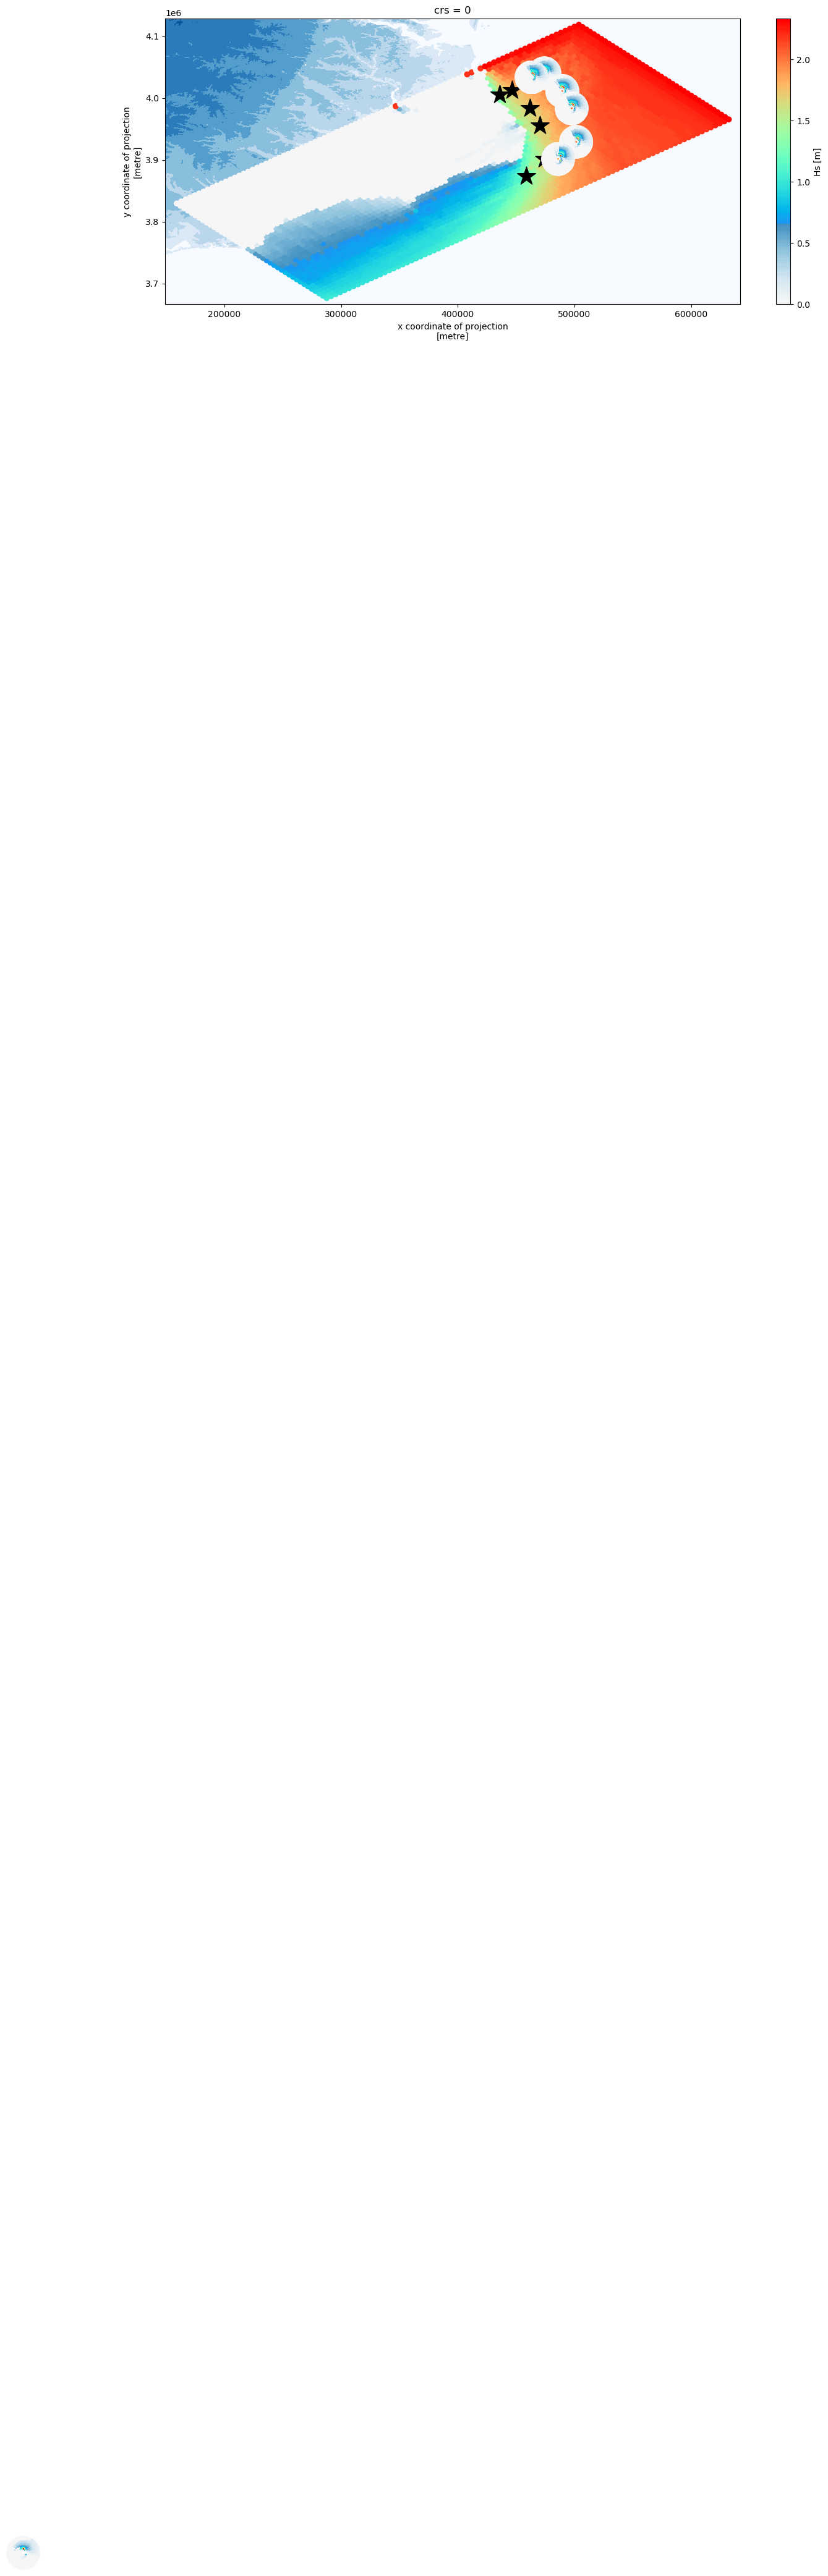

In [8]:
import xarray as xr
import matplotlib.image as mimg
import importlib
import utils.plotting as plotting
importlib.reload(plotting)
from utils.plotting import plot_spectrum_in_coastline

import importlib
import utils.plotting as plotting

time_to_plot = "2022-02-20 12:00"

# Plot the spectrum along the coastline
bathy = xr.open_dataset("common_inputs/bathy_north_carolina_rotated.nc").elevation.T
# ortophoto = mimg.imread("outputs/ortophoto_cantabria.png")
plot_spectrum_in_coastline(
    bathy=bathy,
    reconstructed_onshore_spectra=reconstructed_onshore_spectra.rename({"kps": "kp"}),
    reconstruction_kps=kp_coeffs,
    offshore_spectra=offshore_spectra,
    time_to_plot=time_to_plot,
    # sites_for_spectrum=[17, 88],
    sites_for_spectrum=list(range(-6, 0))
    # ortophoto=ortophoto,
)

# plot_spectrum_in_coastline(bathy, reconstructed_spectra, kps, offshore_spectra)

In [5]:
# # Convert to GeoJSON and save
# import json
# from pyproj import Transformer

# # Create the transformer object for UTM Zone 18N (North Carolina)
# transformer = Transformer.from_crs(
#     "EPSG:32618",  # UTM zone 18N - correct for North Carolina
#     "EPSG:4326",   # WGS84
#     always_xy=True
# )

# # Determine number of points and calculate padding length
# num_points = len(reconstructed_onshore_spectra.utm_x.values)
# id_padding_length = len(str(num_points)) + 1

# # Create GeoJSON features list
# features = []

# # Loop through each point
# for i, (x, y) in enumerate(zip(
#     reconstructed_onshore_spectra.utm_x.values,
#     reconstructed_onshore_spectra.utm_y.values,
# )):
#     # Convert UTM to WGS84 (output will be lon, lat)
#     lon, lat = transformer.transform(x, y)
    
#     # Create ID with leading zeros
#     point_id = str(i).zfill(id_padding_length)
    
#     # Create feature
#     feature = {
#         "type": "Feature",
#         "properties": {
#             "id": point_id,
#             "type": "BinWaves"
#         },
#         "geometry": {
#             "type": "Point",
#             "coordinates": [lon, lat]
#         }
#     }
#     features.append(feature)

# # Create the full GeoJSON structure
# geojson = {
#     "type": "FeatureCollection",
#     "features": features
# }

# # Save to file
# with open('reconstructed_spectra.json', 'w') as f:
#     json.dump(geojson, f, indent=2)

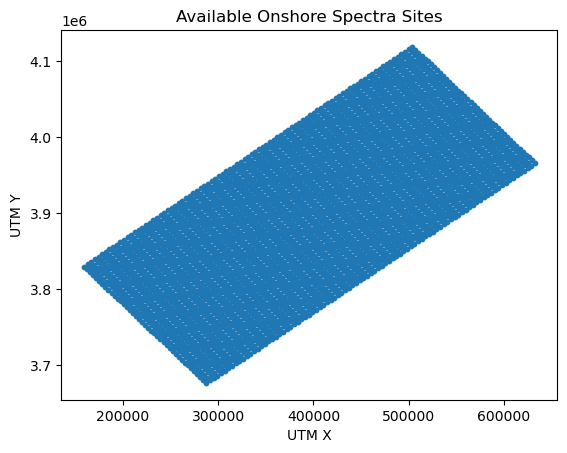

In [6]:
import matplotlib.pyplot as plt

plt.scatter(
    reconstructed_onshore_spectra.utm_x.values,
    reconstructed_onshore_spectra.utm_y.values,
    s=10
)
plt.xlabel("UTM X")
plt.ylabel("UTM Y")
plt.title("Available Onshore Spectra Sites")
plt.show()